# Fouille de données de compteurs électriques (A)
![](https://deptinfo-ensip.univ-poitiers.fr/blank/TP_2A_fouille_donnees_A-sujet.ipynb:egarre06)

In [1]:
from IPython.display import HTML
HTML(url="https://ensip.gitlab.io/notebooks/data/nb2.css")

**Les fichiers de données contenant des données électriques que vous allez manipuler ont été fournis par un ancien élève de l'école (N.J.). Il a utilisé ces données lors de son stage de fin d'études, et les a anonymisées avant de nous les fournir, avec l'accord de Gérédis Deux-Sèvres.**

## Lecture des données

Le fichier `CdC_all_PDS_2015_2018_an.json.gz` contient les courbes de
charge d'un peu plus de 400 compteurs, sur environ 3 ans. Il y a un relevé toutes
les 30 minutes, et donc un peu plus de 50 000 relevés par compteur. Chaque valeur
est une donnée en Watts. Commencez par
[charger le fichier `CdC_all_PDS_2015_2018_an.json.gz`](https://ensip.gitlab.io/notebooks/data/linky/CdC_all_PDS_2015_2018_an.json.gz)
et enregistrez le, au même endroit que votre notebook, sans modifier son nom.

La cellule suivante charge le fichier complet (il est compressé, l'utilisation du module `gzip` 
permet de décompresser), puis interprète son contenu comme du format JSON. Finalement, 
depuis Python, on récupère une structure de données standard, ici un dictionnaire.

In [4]:
from pathlib import Path
import gzip
import json
contenu_fichier = gzip.open(Path("CdC_all_PDS_2015_2018_an.json.gz")).read()
res = json.loads(contenu_fichier)
type(res)

dict

> Il va falloir dans un premier temps découvrir ce qui est dans `res`.
> Combien y a t il de compteurs exactement ? Les enregistrements vont de quelle date à quelle date ? Combien y a t il de points de mesure sur cette plage de temps ?
> Répondez à ces questions dans la cellule ci-dessous (vous pouvez ajouter des cellules).

In [7]:
len(res)

403

In [8]:
res.keys()

dict_keys(['dates', '870662EC1', '27712EC1', '59914EC1', '2094EC1', '427957EC1', '81712EC1', '5081EC1', '99973EC1', '582005EC1', '768175EC1', '632605EC1', '13013EC1', '82903EC1', '9191EC1', '69651EC1', '31179EC1', '24687EC1', '60659EC1', '32753EC1', '5508EC1', '1401EC1', '79573EC1', '94821EC1', '66851EC1', '19582EC1', '16006EC1', '39053EC1', '579631EC1', '90402EC1', '12158EC1', '999748EC1', '917276EC1', '894660EC1', '94920EC1', '21903EC1', '29493EC1', '572620EC1', '427054EC1', '39157EC1', '14795EC1', '654801EC1', '621261EC1', '6868EC1', '935236EC1', '5533EC1', '649118EC1', '92204EC1', '6119EC1', '46994EC1', '57251EC1', '74739EC1', '642189EC1', '29663EC1', '586117EC1', '98944EC1', '37057EC1', '40178EC1', '50892EC1', '84408EC1', '405236EC1', '240689EC1', '81152EC1', '36188EC1', '631005EC1', '915822EC1', '66998EC1', '82102EC1', '2946EC1', '50841EC1', '70178EC1', '72722EC1', '79446EC1', '971921EC1', '1525EC1', '379492EC1', '76826EC1', '78928EC1', '950165EC1', '13137EC1', '96503EC1', '79023

In [11]:
res['dates'][:5]

['2015-07-01 00:00:00',
 '2015-07-01 00:30:00',
 '2015-07-01 01:00:00',
 '2015-07-01 01:30:00',
 '2015-07-01 02:00:00']

In [12]:
res['dates'][-5:]

['2018-06-30 21:30:00',
 '2018-06-30 22:00:00',
 '2018-06-30 22:30:00',
 '2018-06-30 23:00:00',
 '2018-06-30 23:30:00']

In [13]:
len(res['dates'])

52608

In [15]:
len(res['48630EC1'])

52608

## Gestion des dates

> Python sait gérer les dates. Construisez une nouvelle liste contenant des objets de type `datetime.datetime` plutôt que des chaînes de caractères. Ceci permettra d'utiliser ces dates en abcisses de courbes, de calculer directement le temps qui sépare deux dates etc.

In [30]:
from datetime import date,datetime, timedelta
Dates =  [datetime.strptime(d,"%Y-%m-%d %H:%M:%S") for d in res['dates']]

**Explication de la réponse ci-dessus :**
Cette réponse sert à convertir des chaînes de caractères représentant des dates en véritables objets `datetime` manipulables en Python. La liste en compréhension parcourt la liste des dates sous forme de texte, et `datetime.strptime` les traduit en utilisant le format spécifié (Année-Mois-Jour Heure:Minute:Seconde).

In [31]:
Dates[:5]

[datetime.datetime(2015, 7, 1, 0, 0),
 datetime.datetime(2015, 7, 1, 0, 30),
 datetime.datetime(2015, 7, 1, 1, 0),
 datetime.datetime(2015, 7, 1, 1, 30),
 datetime.datetime(2015, 7, 1, 2, 0)]

## Affichage d'une courbe de charge

> Afficher la courbe de charge du compteur `870662EC1`, durant la journée du 1 juillet 2015. Les abcisses doivent représenter la date et l'heure et doivent être lisibles (non superposées)

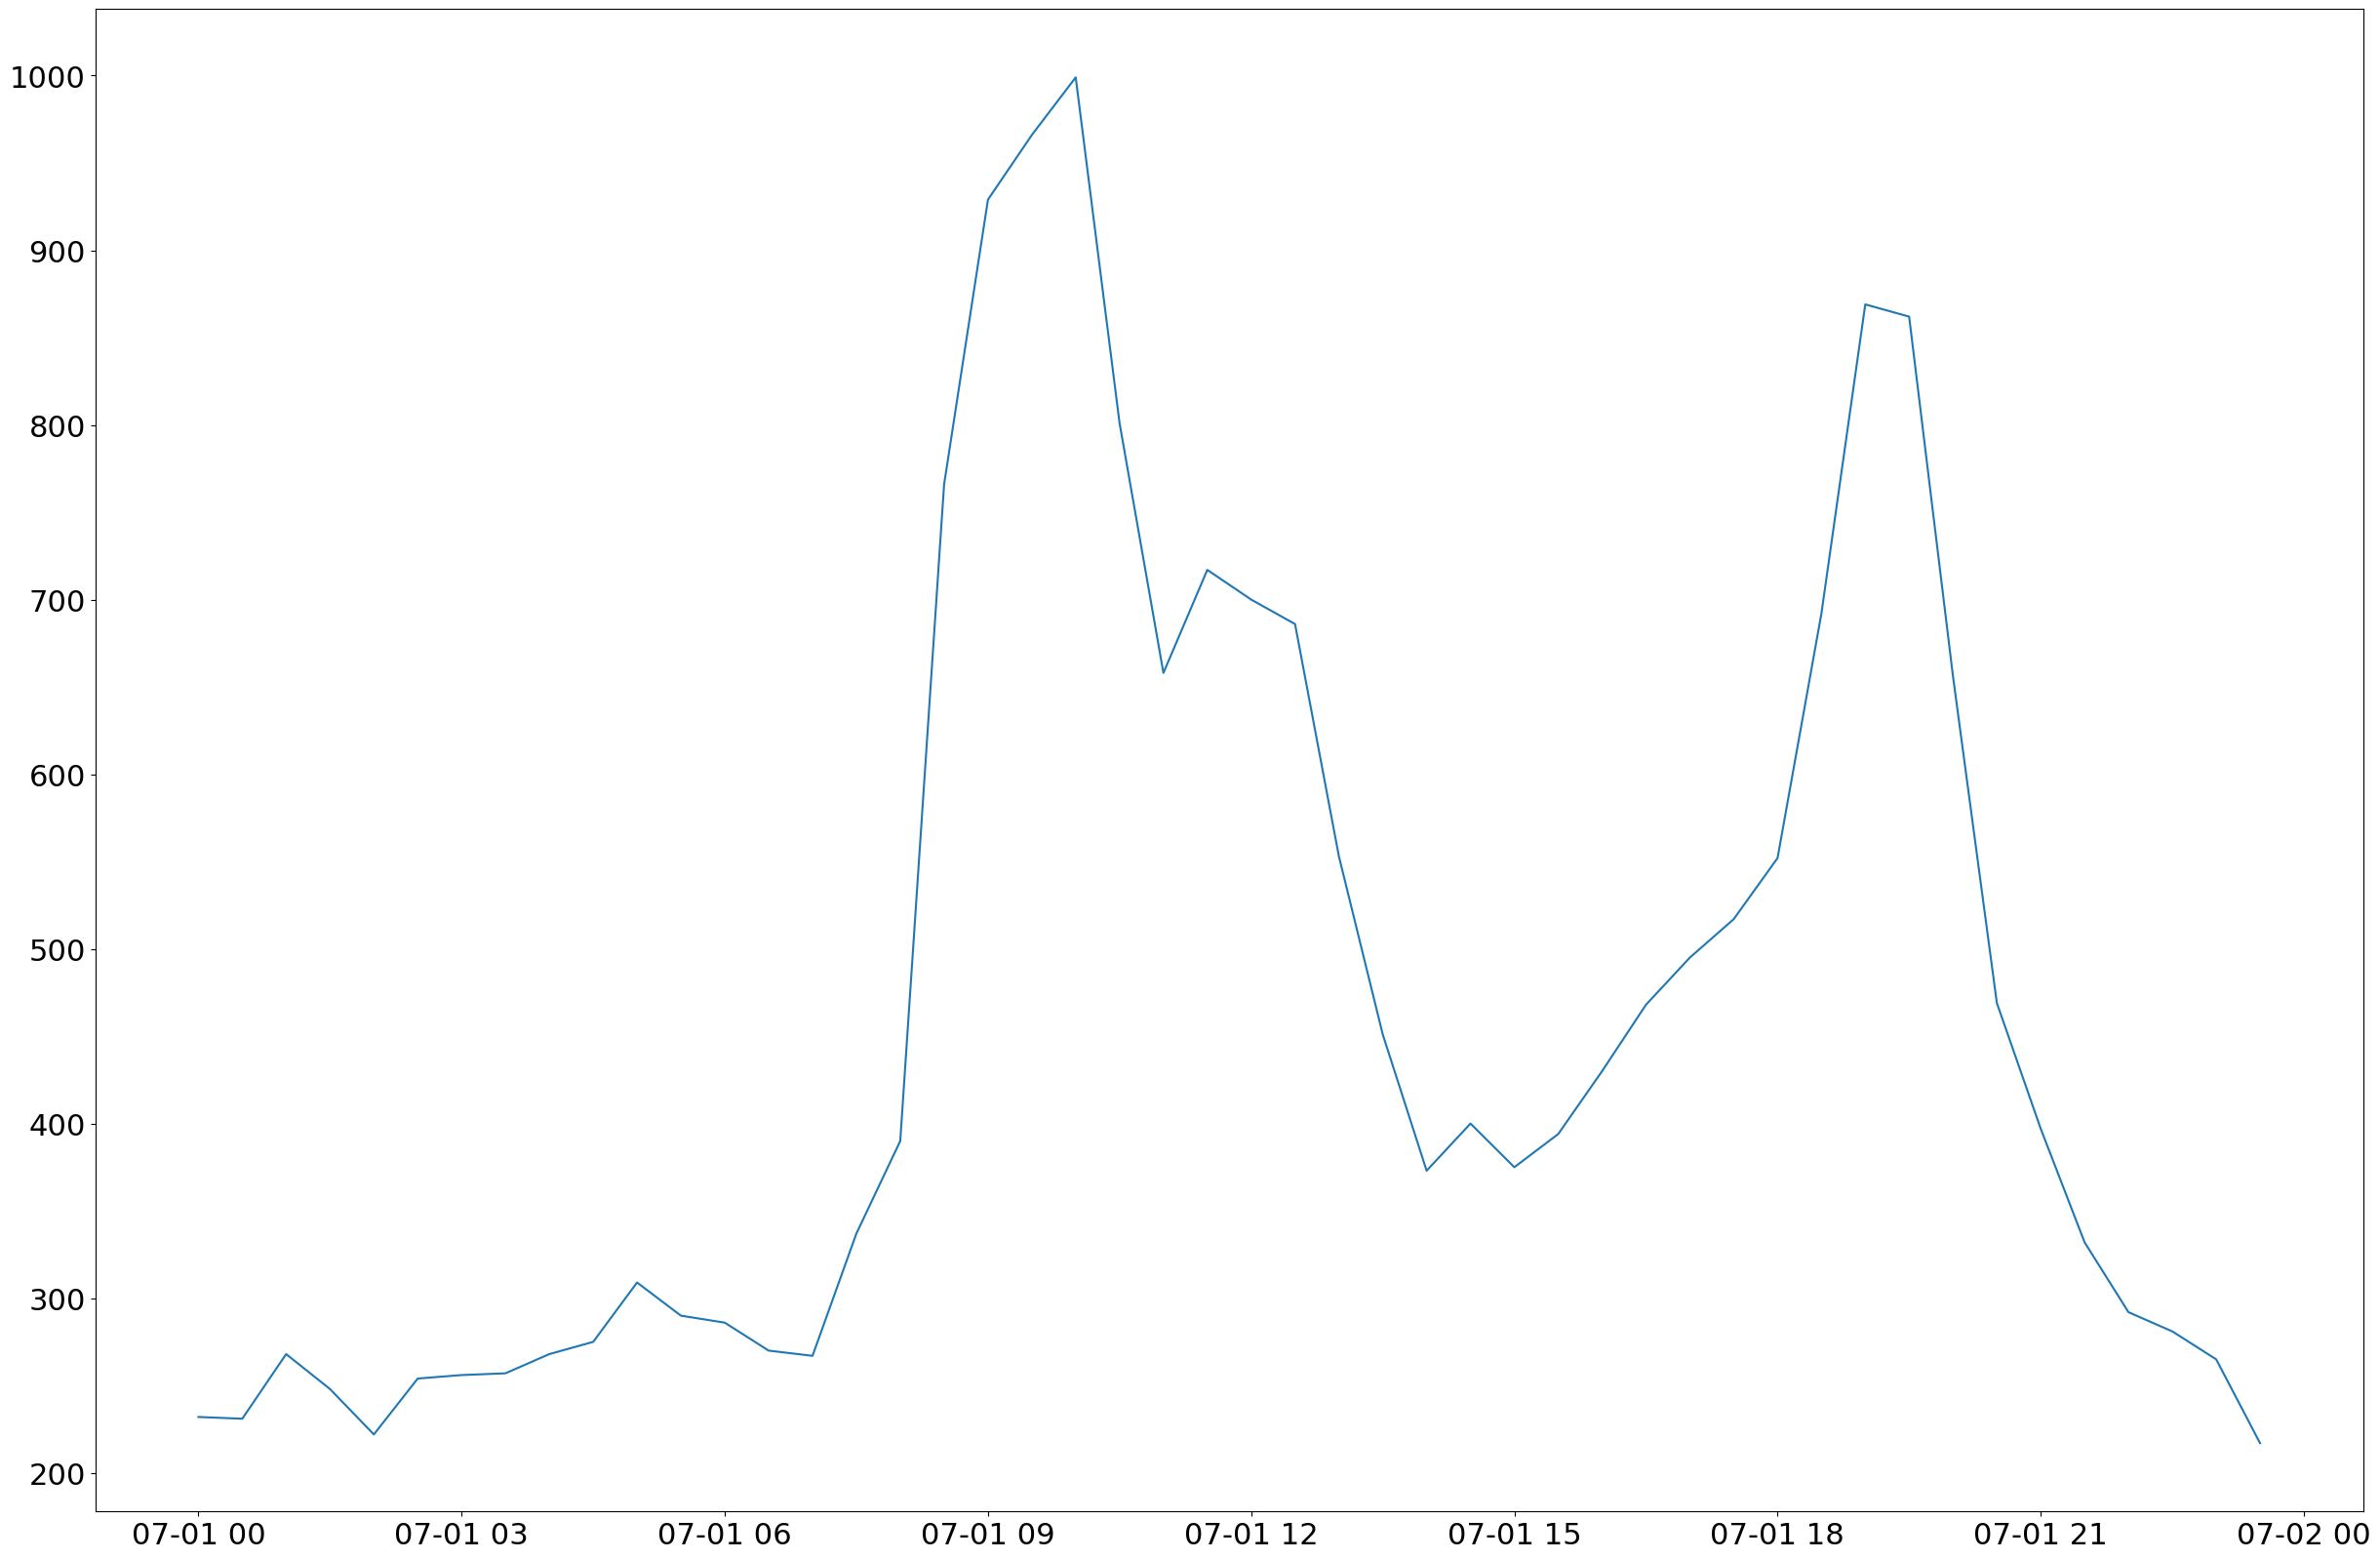

In [34]:
import matplotlib.pyplot as plt

y = res['870662EC1'][:48] 
plt.plot(Dates[:48],y)
svtaille = plt.rcParams.copy()
plt.rcParams.update({'font.size': 22})
plt.rcParams.update({"figure.figsize": (30, 20)})
plt.rcParams = svtaille 

**Explication de la réponse ci-dessus :**
Cette réponse permet de visualiser la courbe de charge (consommation) d'un compteur ('870662EC1') sur les 48 premières mesures. Elle utilise `matplotlib.pyplot` pour tracer le graphique (`plt.plot`), et modifie les paramètres globaux `plt.rcParams` pour agrandir la taille de la police et la taille de la figure afin que le graphique soit bien lisible.

## Moyennes mensuelles pour 2016

> Pour le compteur `27712EC1`, réalisez des moyennes de consommation mensuelles sur l'année 2016, et tracez cette nouvelle courbe. Vous devez avoir un point par mois, et le nom du mois en abcisse.


In [46]:
sommes = [0]*12
nbmesures = [0]*12
for d,w in zip(Dates, res['27712EC1']):
    if d.year == 2016:
        m = d.month -1
        sommes[m] = sommes[m]+w
        nbmesures[m] = nbmesures[m]+1
resultat = [w/n]      

**Explication de la réponse ci-dessus :**
Cette réponse calcule la consommation moyenne mensuelle pour un compteur spécifique (27712EC1) sur l'année 2016. Une boucle parcourt simultanément les dates et les mesures. Si l'année est 2016, on ajoute la valeur au mois correspondant (`sommes[m]`) et on compte le nombre de mesures (`nbmesures[m]`) pour pouvoir en déduire une moyenne par mois.

## Analyse par poste source

Le fichier `extrait_SIG_an.csv` est un fichier csv contenant des références de compteurs,
a puissance souscrite, ainsi que le le numéro du départ. 
Le numéro du départ est composé de 2 nombres. La première partie (5 chiffres) correspond
au poste source HTA/BT de raccordement. La seconde (3 chiffres) correspond au départ BT sur
ce poste source. Il y a plusieurs compteurs par départ BT.

[Téléchargez le fichier](https://ensip.gitlab.io/notebooks/data/linky/extrait_SIG_an.csv),
**sans modifier son nom**,
et procédez comme précédemment pour le lire.

> Affichez le début du fichier csv pour voir comment il est construit

> Lisez le fichier csv et organisez le de manière à pouvoir obtenir facilement, par la suite, les puissances souscrites (sous forme de float) et les numéros de départ pour chaque compteur (sous forme de chaîne). Autrement dit, on veut disposer d'une structure de données qui, si on lui donne le compteur, permet d'obtenir instantanément la puissance souscrite et le numéro du départ.

> Construisez la liste des références des compteurs reliés au même départ que le compteur `27712EC1`. Combien y en a-t-il ?

> Quelle est la puissance maximum que ce départ a dû fournir au cours des années 2016 et 2017 ?